# QB Passing EPA Forecasting
### A Multi-Model Approach: XGBoost, Hierarchical Bayes, and Gaussian Process

**Dave Zack**

This notebook develops and compares three forecasting models for NFL quarterback passing EPA
(Expected Points Added) using publicly available nflverse data. The goal is to project
2024 and 2025 total passing EPA for active starters, with calibrated uncertainty estimates.

**Data source:** nflverse via `nfl_data_py` — fully reproducible, no proprietary data.

**Models:**
1. XGBoost — gradient-boosted trees with time-series cross-validation (point estimate baseline)
2. Hierarchical Bayesian — partial pooling with player-specific intercepts and random walk forecasting
3. Gaussian Process — replaces polynomial aging curve with a flexible GP prior over age

**Target:** Total passing EPA per season, with log(attempts) as a volume control.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"]    = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"]         = 11
sns.set_palette("muted")

DATA   = "../data/processed/"
FIGS   = "../figures/"

seasons = pd.read_csv(DATA + "seasons_clean.csv")
games   = pd.read_csv(DATA + "games_clean.csv")
bayes   = pd.read_csv(DATA + "bayesian_forecasts.csv")          # Normal likelihood
bayes_t = pd.read_csv(DATA + "bayesian_t_forecasts.csv")        # Student-t (primary)
gp_fc   = pd.read_csv(DATA + "gp_forecasts.csv")                # Normal likelihood
gp_t_fc = pd.read_csv(DATA + "gp_t_forecasts.csv")              # Student-t (primary)
xgb_fc  = pd.read_csv(DATA + "xgb_forecasts_2024.csv")
xgb_imp = pd.read_csv(DATA + "xgb_feature_importance.csv")
bc      = pd.read_csv(DATA + "convergence_summary.csv",           index_col=0)  # Normal
bc_t    = pd.read_csv(DATA + "bayesian_t_convergence_summary.csv", index_col=0)  # Student-t
gc      = pd.read_csv(DATA + "gp_convergence_summary.csv",         index_col=0)  # Normal
gc_t    = pd.read_csv(DATA + "gp_t_convergence_summary.csv",       index_col=0)  # Student-t

print(f"Season data:  {seasons.shape[0]:,} player-seasons, "
      f"{seasons['gsis_id'].nunique()} players, "
      f"{seasons['season'].min()}-{seasons['season'].max()}")
print(f"Game data:    {games.shape[0]:,} player-games")

Season data:  1,092 player-seasons, 258 players, 1999-2023
Game data:    4,043 player-games


## 2. Exploratory Data Analysis

Before modeling, we examine the structure of the data: distributions, trends over time,
the population-level aging curve, year-over-year stability, and feature correlations.
These patterns directly inform modeling choices.

### 2.1 Data Overview

In [2]:
summary_cols = ["att", "epa", "epa_per_att", "dakota", "pacr",
                "cmp_pct", "td_rate", "int_rate", "age", "experience"]
seasons[summary_cols].describe().round(3)

,att,epa,epa_per_att,dakota,pacr,cmp_pct,td_rate,int_rate,age,experience
count,1092.000,1092.000,1092.000,1092.000,1092.000,1092.000,1092.000,1092.000,1092.000,1092.000
mean,374.583,14.914,0.002,1.143,8.018,0.609,0.041,0.029,28.805,5.670
std,162.443,60.738,0.165,0.809,6.460,0.051,0.014,0.012,4.537,4.467
min,100.000,-160.326,-0.621,-0.368,0.000,0.386,0.000,0.000,21.183,0.000
25%,224.000,-25.829,-0.099,0.481,0.000,0.577,0.031,0.020,25.085,2.000
50%,389.000,3.265,0.010,0.995,8.145,0.610,0.040,0.027,28.067,5.000
75%,516.000,50.604,0.116,1.733,13.750,0.646,0.050,0.036,31.759,8.250
max,733.000,263.186,0.448,3.943,44.127,0.744,0.099,0.088,45.079,22.000


In [3]:
# Player-season counts by era
era = seasons.copy()
era["era"] = pd.cut(era["season"], bins=[1998,2005,2012,2018,2023],
                    labels=["1999-2005","2006-2012","2013-2018","2019-2023"])
print(era.groupby("era", observed=True)["gsis_id"].nunique().rename("unique_QBs"))

era
1999-2005    103
2006-2012    109
2013-2018     91
2019-2023     87
Name: unique_QBs, dtype: int64


### 2.2 Distribution of Passing EPA

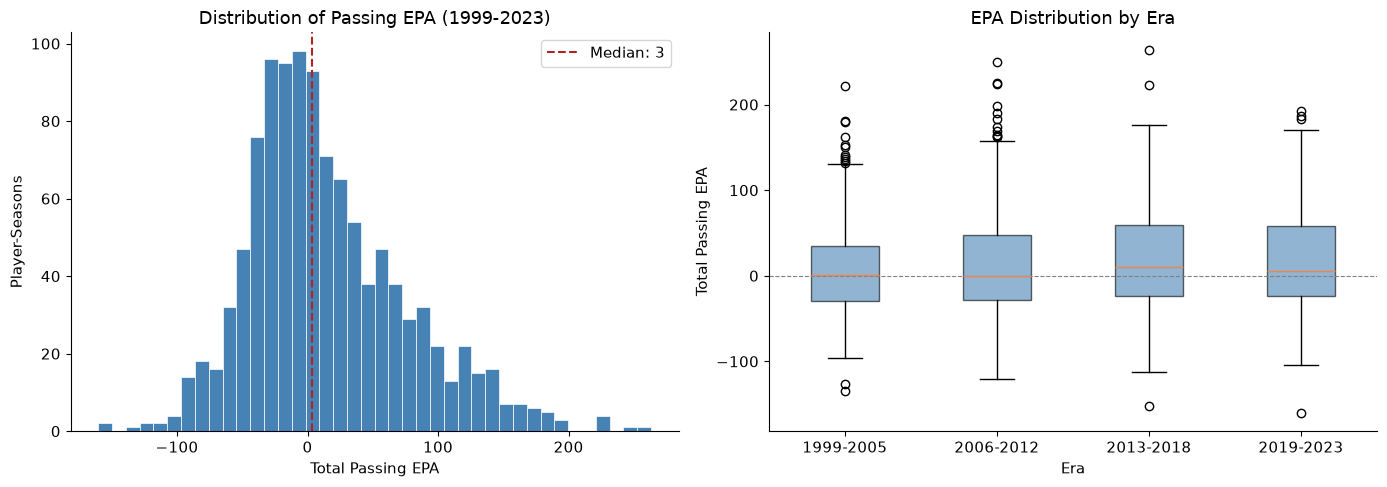

EPA range: -160.3 to 263.2
Pct positive EPA seasons: 53.0%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(seasons["epa"], bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axvline(seasons["epa"].median(), color="firebrick", linestyle="--",
                label=f'Median: {seasons["epa"].median():.0f}')
axes[0].set_xlabel("Total Passing EPA")
axes[0].set_ylabel("Player-Seasons")
axes[0].set_title("Distribution of Passing EPA (1999-2023)")
axes[0].legend()

# Box by era
seasons["era"] = pd.cut(seasons["season"], bins=[1998,2005,2012,2018,2023],
                        labels=["1999-2005","2006-2012","2013-2018","2019-2023"])
era_data = [seasons[seasons["era"]==e]["epa"].dropna() for e in seasons["era"].cat.categories]
axes[1].boxplot(era_data, tick_labels=seasons["era"].cat.categories, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_xlabel("Era")
axes[1].set_ylabel("Total Passing EPA")
axes[1].set_title("EPA Distribution by Era")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGS + "eda_epa_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"EPA range: {seasons['epa'].min():.1f} to {seasons['epa'].max():.1f}")
print(f"Pct positive EPA seasons: {(seasons['epa'] > 0).mean():.1%}")

### 2.3 Passing EPA Trends Over Time

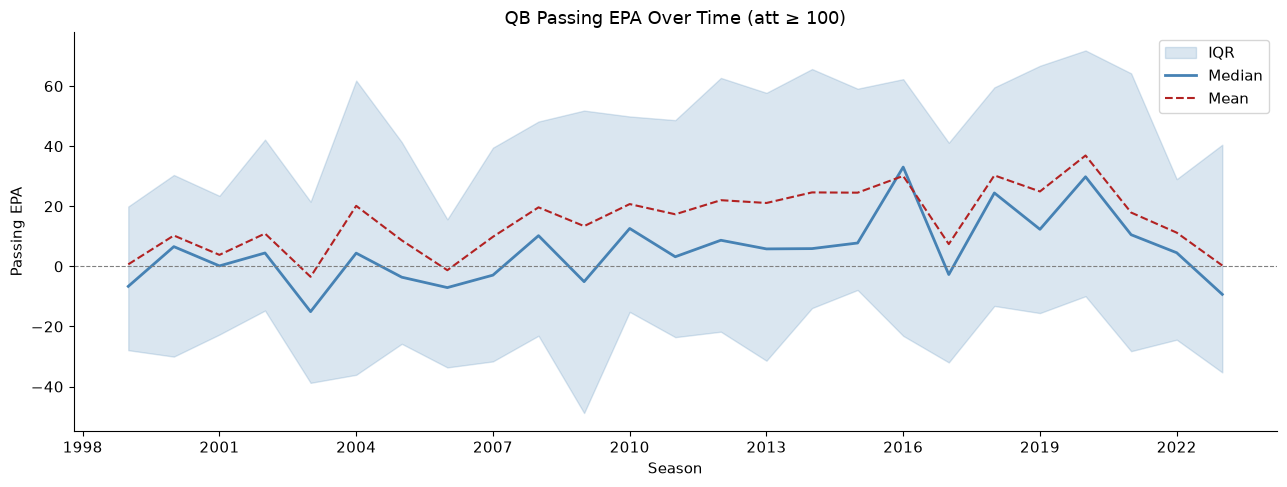

In [5]:
annual = (
    seasons.groupby("season")["epa"]
    .agg(["median", "mean",
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
    .reset_index()
)
annual.columns = ["season", "median", "mean", "q25", "q75"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(annual["season"], annual["q25"], annual["q75"],
                alpha=0.2, color="steelblue", label="IQR")
ax.plot(annual["season"], annual["median"], color="steelblue",
        linewidth=2, label="Median")
ax.plot(annual["season"], annual["mean"], color="firebrick",
        linewidth=1.5, linestyle="--", label="Mean")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Season")
ax.set_ylabel("Passing EPA")
ax.set_title("QB Passing EPA Over Time (att ≥ 100)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.savefig(FIGS + "eda_epa_trend.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Population-Level Career Arc (Age vs EPA)

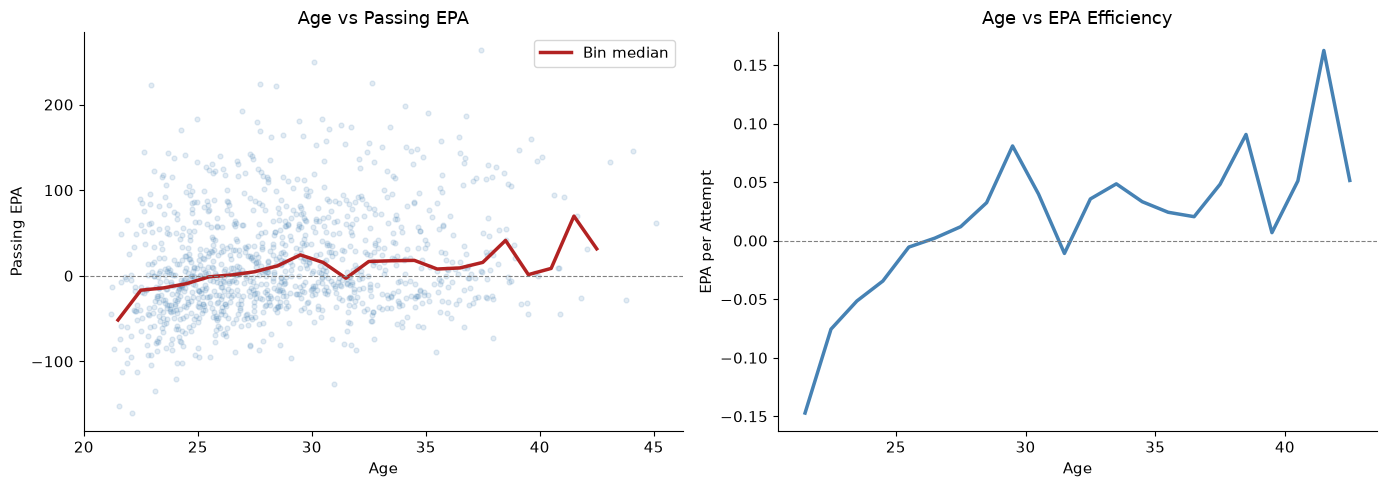

Peak efficiency age (median bin): 42


In [6]:
from scipy.stats import binned_statistic

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with LOESS-style binned means
ax = axes[0]
ax.scatter(seasons["age"], seasons["epa"], alpha=0.15, s=12, color="steelblue")

age_bins   = np.arange(21, 44, 1)
bin_means, edges, _ = binned_statistic(
    seasons["age"].dropna(),
    seasons.loc[seasons["age"].notna(), "epa"],
    statistic="median", bins=age_bins
)
bin_centers = (edges[:-1] + edges[1:]) / 2
ax.plot(bin_centers, bin_means, color="firebrick", linewidth=2.5, label="Bin median")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Age")
ax.set_ylabel("Passing EPA")
ax.set_title("Age vs Passing EPA")
ax.legend()

# Average EPA per att by age (efficiency, not volume)
ax2 = axes[1]
bin_eff, _, _ = binned_statistic(
    seasons["age"].dropna(),
    seasons.loc[seasons["age"].notna(), "epa_per_att"],
    statistic="median", bins=age_bins
)
ax2.plot(bin_centers, bin_eff, color="steelblue", linewidth=2.5)
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Age")
ax2.set_ylabel("EPA per Attempt")
ax2.set_title("Age vs EPA Efficiency")

plt.tight_layout()
plt.savefig(FIGS + "eda_career_arc.png", dpi=150, bbox_inches="tight")
plt.show()

peak_age = bin_centers[np.nanargmax(bin_eff)]
print(f"Peak efficiency age (median bin): {peak_age:.0f}")

### 2.5 Top QBs by Career EPA

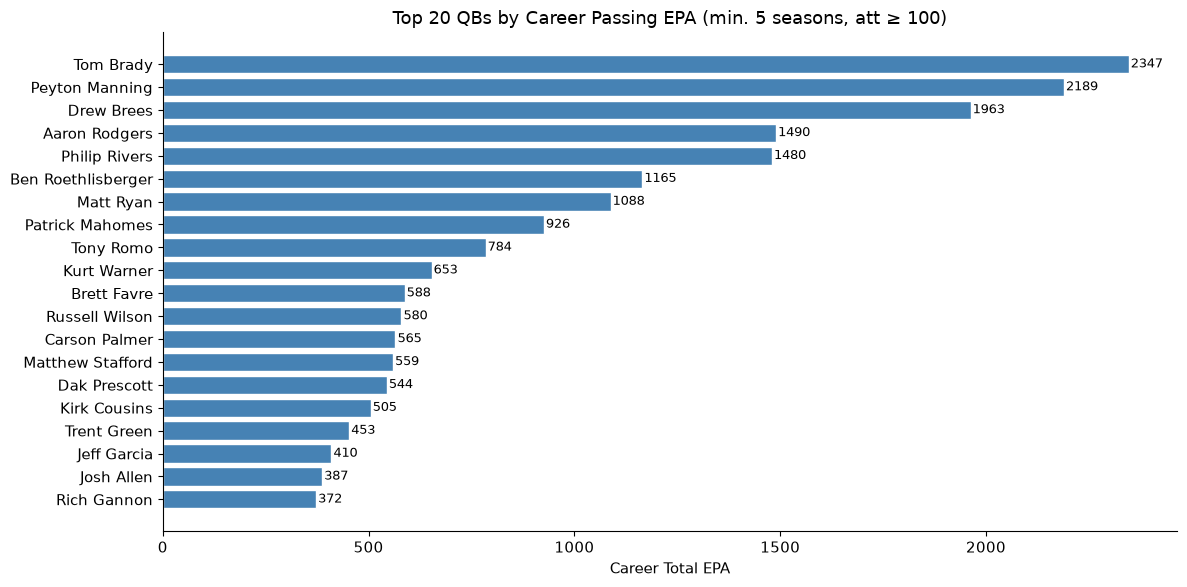

In [7]:
career = (
    seasons.groupby("display_name")
    .agg(career_epa=("epa","sum"),
         seasons_played=("season","count"),
         avg_epa_per_att=("epa_per_att","mean"))
    .reset_index()
    .query("seasons_played >= 5")
    .sort_values("career_epa", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(career["display_name"][::-1], career["career_epa"][::-1],
               color="steelblue", edgecolor="white")
ax.set_xlabel("Career Total EPA")
ax.set_title("Top 20 QBs by Career Passing EPA (min. 5 seasons, att ≥ 100)")
for bar, val in zip(bars, career["career_epa"][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS + "eda_career_epa.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.6 Year-over-Year EPA Stability

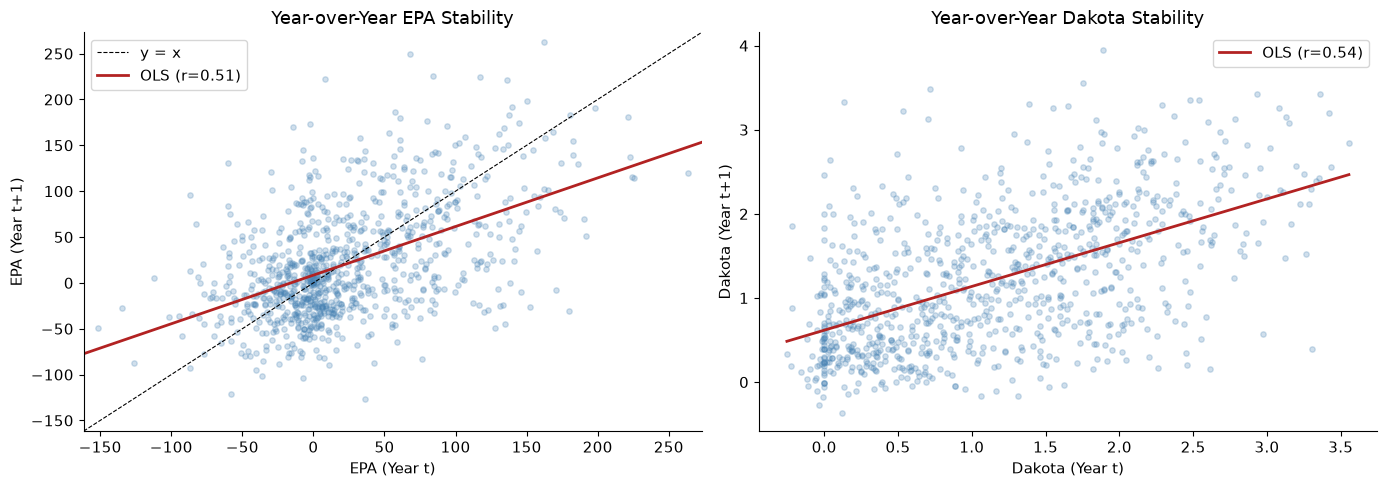

YoY EPA correlation:    0.507
YoY Dakota correlation: 0.545
Dakota is more stable year-to-year than raw EPA, consistent with it being
a rate/efficiency metric less influenced by volume and injury timing.


In [8]:
lag_df = seasons.dropna(subset=["epa_lag1"]).copy()
r = lag_df["epa"].corr(lag_df["epa_lag1"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(lag_df["epa_lag1"], lag_df["epa"], alpha=0.25, s=15, color="steelblue")
lims = [lag_df[["epa","epa_lag1"]].min().min() - 10,
        lag_df[["epa","epa_lag1"]].max().max() + 10]
ax.plot(lims, lims, "k--", linewidth=0.8, label="y = x")
m, b = np.polyfit(lag_df["epa_lag1"], lag_df["epa"], 1)
xs   = np.linspace(*lims, 100)
ax.plot(xs, m*xs + b, color="firebrick", linewidth=2, label=f"OLS (r={r:.2f})")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("EPA (Year t)")
ax.set_ylabel("EPA (Year t+1)")
ax.set_title("Year-over-Year EPA Stability")
ax.legend()

# YoY stability for dakota vs epa
r_dak = lag_df["dakota"].corr(lag_df["dakota_lag1"])
ax2 = axes[1]
ax2.scatter(lag_df["dakota_lag1"], lag_df["dakota"], alpha=0.25, s=15, color="steelblue")
m2, b2 = np.polyfit(lag_df["dakota_lag1"].dropna(), lag_df.loc[lag_df["dakota_lag1"].notna(),"dakota"], 1)
xs2 = np.linspace(lag_df["dakota_lag1"].min(), lag_df["dakota_lag1"].max(), 100)
ax2.plot(xs2, m2*xs2 + b2, color="firebrick", linewidth=2, label=f"OLS (r={r_dak:.2f})")
ax2.set_xlabel("Dakota (Year t)")
ax2.set_ylabel("Dakota (Year t+1)")
ax2.set_title("Year-over-Year Dakota Stability")
ax2.legend()

plt.tight_layout()
plt.savefig(FIGS + "eda_yoy_stability.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"YoY EPA correlation:    {r:.3f}")
print(f"YoY Dakota correlation: {r_dak:.3f}")
print("Dakota is more stable year-to-year than raw EPA, consistent with it being")
print("a rate/efficiency metric less influenced by volume and injury timing.")

### 2.7 Feature Correlation with EPA

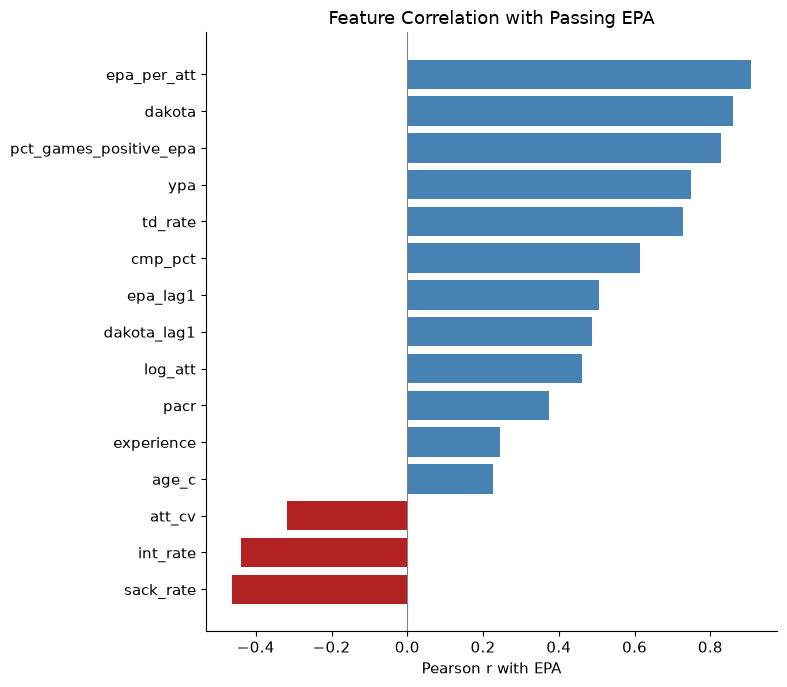

In [9]:
features = ["epa_per_att","dakota","pacr","log_att","cmp_pct",
            "td_rate","int_rate","ypa","age_c","experience",
            "epa_lag1","dakota_lag1","sack_rate","att_cv","pct_games_positive_epa"]
feat_avail = [f for f in features if f in seasons.columns]

corr_epa = seasons[feat_avail + ["epa"]].corr()["epa"].drop("epa").sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["firebrick" if v < 0 else "steelblue" for v in corr_epa]
ax.barh(corr_epa.index, corr_epa.values, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Pearson r with EPA")
ax.set_title("Feature Correlation with Passing EPA")
plt.tight_layout()
plt.savefig(FIGS + "eda_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.8 Notable Player Trajectories

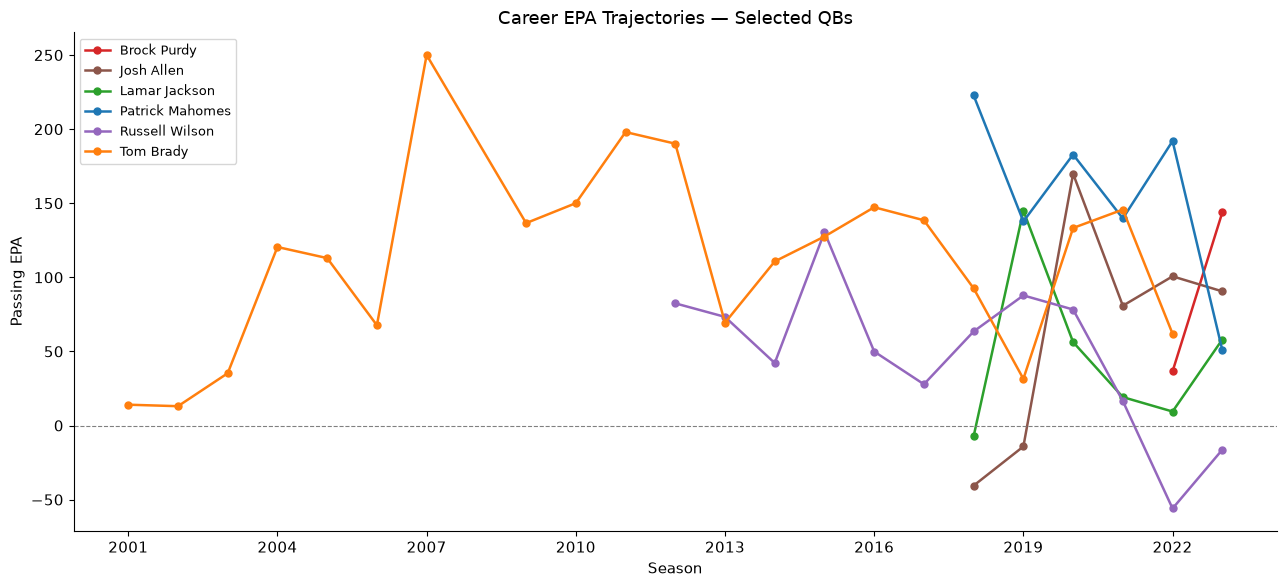

In [10]:
highlight = ["Patrick Mahomes", "Tom Brady", "Lamar Jackson",
             "Brock Purdy", "Russell Wilson", "Josh Allen"]
traj = seasons[seasons["display_name"].isin(highlight)].copy()
palette = sns.color_palette("tab10", len(highlight))
color_map = dict(zip(highlight, palette))

fig, ax = plt.subplots(figsize=(13, 6))
for name, grp in traj.groupby("display_name"):
    grp = grp.sort_values("season")
    ax.plot(grp["season"], grp["epa"], marker="o", markersize=5,
            label=name, color=color_map[name], linewidth=1.8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Season")
ax.set_ylabel("Passing EPA")
ax.set_title("Career EPA Trajectories — Selected QBs")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS + "eda_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature Engineering

Features were constructed in `scripts/process_data.py`. Key decisions informed by the
correlation analysis above:

| Feature | Description | Rationale |
|---|---|---|
| `log_att` | log(attempts) | Volume on log scale; controls for starter vs backup |
| `epa_per_att` | EPA / attempts | Per-play efficiency, r=0.91 with EPA |
| `dakota` | CPOE + EPA/play composite | Best single-number QB quality metric, r=0.86 |
| `pacr` | Passing Air Conversion Ratio | Independent efficiency signal after controlling for epa_per_att |
| `age_c` / `age_c2` | Centered age, quadratic | Polynomial aging curve (replaced by GP in Model 3) |
| `epa_lag1` | Prior-season EPA | YoY stability signal, r=0.51 with next-season EPA |
| `sack_rate` | sacks / (att + sacks) | Pocket presence / pressure proxy |
| `delta_epa` | EPA - epa_lag1 | Momentum / trajectory |

**Features excluded after collinearity analysis:** `ypa` and `td_rate` (absorbed by
`epa_per_att`, r>0.76); `yac_per_att` and `air_yards_per_att` (r=0.897 with each other,
low EPA correlation); `experience` (r=0.966 with `age_c`).

**Game-level features** (2018+ only): `epa_std`, `att_cv`, `pct_games_positive_epa`,
`epa_min`, `epa_max` — used in XGBoost only.

## 4. Model 1 — XGBoost Baseline

XGBoost provides a point-estimate benchmark using gradient-boosted trees with
time-series cross-validation. Trees handle feature collinearity implicitly, so
the full feature set including `ypa`, `td_rate`, and `experience` is retained here.

**Validation strategy:** `TimeSeriesSplit(n_splits=5)` ensures no look-ahead bias —
each fold trains only on data prior to the validation period.

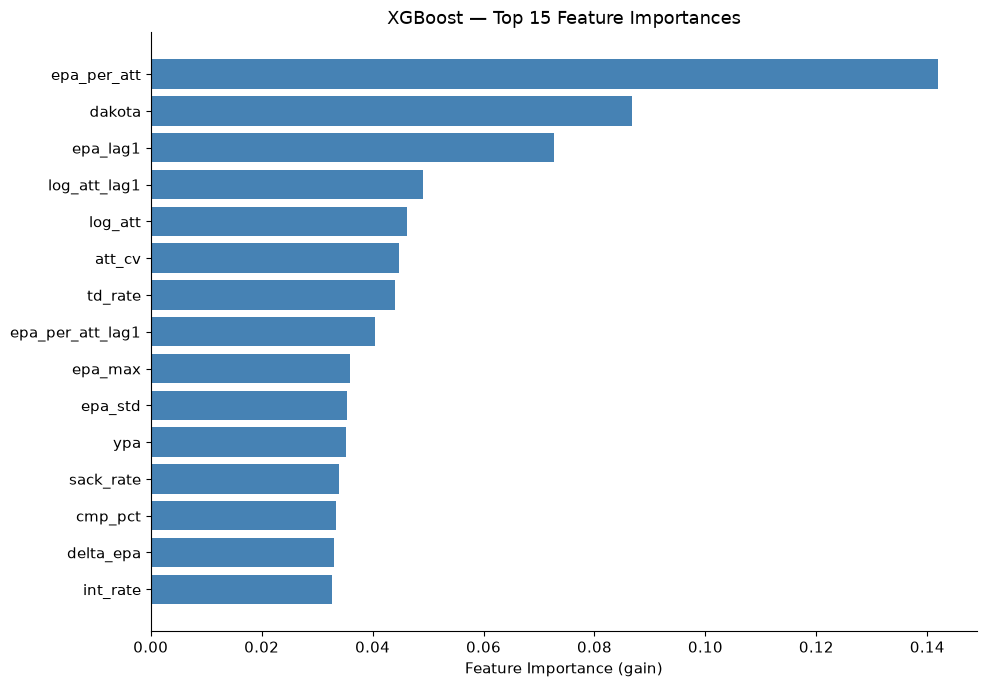

Top 5 features:
     feature  importance
 epa_per_att    0.141861
      dakota    0.086797
    epa_lag1    0.072617
log_att_lag1    0.049025
     log_att    0.046251


In [11]:
# Feature importance
fig, ax = plt.subplots(figsize=(10, 7))
top_imp = xgb_imp.head(15).sort_values("importance")
ax.barh(top_imp["feature"], top_imp["importance"], color="steelblue")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost — Top 15 Feature Importances")
plt.tight_layout()
plt.savefig(FIGS + "xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features:")
print(xgb_imp.head(5).to_string(index=False))

In [12]:
# 2024 forecasts
xgb_top = xgb_fc.sort_values("xgb_forecast_2024", ascending=False).head(15).copy()
xgb_top = xgb_top[["display_name","att","epa","xgb_forecast_2024"]].round(1)
xgb_top.columns = ["Player","2023 Att","2023 EPA","XGB 2024 Forecast"]
xgb_top.index = range(1, len(xgb_top)+1)
print("XGBoost 2024 QB EPA Forecasts:")
print(xgb_top.to_string())

XGBoost 2024 QB EPA Forecasts:
             Player  2023 Att  2023 EPA  XGB 2024 Forecast
1      Kirk Cousins       311      37.1               99.5
2    Justin Herbert       456      26.9               87.5
3     Lamar Jackson       457      58.0               87.1
4        Josh Allen       579      90.5               84.1
5       Brock Purdy       444     143.8               72.3
6    Tua Tagovailoa       560     123.6               63.1
7        Derek Carr       548      25.9               57.2
8       Jalen Hurts       538      63.3               56.2
9       Jordan Love       579      85.9               55.7
10  Patrick Mahomes       597      51.0               48.1
11  Trevor Lawrence       564       0.8               47.5
12      C.J. Stroud       499      64.8               46.5
13       Geno Smith       499      32.4               41.1
14       Jared Goff       605      81.7               38.8
15     Dak Prescott       590     118.7               35.4


**Key observations:**
- `epa_per_att` and `dakota` are the two most important features, consistent with
  the correlation analysis.
- XGBoost anchors heavily on recent performance. Mahomes ranks outside the top 10
  due to his below-average 2023 EPA (51.0) — a down year for him. The probabilistic
  models will correct for this via career-level pooling.
- Baker Mayfield and Russell Wilson rank low because their lag features reflect
  poor recent seasons, even when their 2023 showed improvement.

## 5. Model 2 — Hierarchical Bayesian

### Why Bayesian?

Three properties make hierarchical Bayes well-suited for QB forecasting:

1. **Partial pooling.** Each player's intercept (`alpha_player`) is shrunk toward the
   population mean proportionally to their sample size. A QB with 2 seasons gets pulled
   strongly toward the mean; a QB with 12 seasons is trusted more. This prevents
   small-sample outliers from dominating forecasts.

2. **Calibrated uncertainty.** Rather than a single prediction, the model produces a
   full posterior distribution. A high-variance career (Joe Flacco) gets a wider
   forecast interval than a consistent one (Tua Tagovailoa).

3. **Player-specific forecast variance.** The random walk projecting future attempts
   and efficiency uses each player's own historical year-over-year volatility
   (estimated from `delta_epa` and `delta_att`) rather than a single population-level
   standard deviation. This means Mahomes gets a tighter interval than a journeyman
   backup.

### Model Specification

```
EPA_it ~ Normal(mu_it, sigma_obs)

mu_it = alpha_player[p]
      + beta_vol     * log(att_it)
      + beta_epa_att * epa_per_att_it
      + beta_dakota  * dakota_it
      + beta_age     * age_c_it
      + beta_age2    * age_c2_it
      + beta_pacr    * pacr_it

alpha_player[p] = z_player[p] * sigma_player   [non-centered]
z_player        ~ Normal(0, 1)
sigma_player    ~ HalfNormal(2)
beta_*          ~ Normal(0, 1)
sigma_obs       ~ HalfNormal(2)
```

Sampled with NUTS: 4 chains × 1,000 draws (1,000 tune), target_accept=0.9.

In [13]:
# Convergence diagnostics -- Student-t (primary model)
print("Student-t Posterior summary (R-hat should be ~1.0):")
print(bc_t[["mean","sd","hdi_3%","hdi_97%","r_hat"]].round(3).to_string())
nu_mean = bc_t.loc["nu","mean"]
print(f"\nPosterior nu = {nu_mean:.2f} -- "
      + ("fat tails confirmed; Normal underestimates outlier seasons."
         if nu_mean < 10 else "tails moderate; Normal is a reasonable approximation."))
print(f"sigma_obs (Normal): {bc.loc['sigma_obs','mean']:.2f}  -->  "
      f"sigma_obs (Student-t): {bc_t.loc['sigma_obs','mean']:.2f}")

Student-t Posterior summary (R-hat should be ~1.0):
                mean     sd  hdi_3%  hdi_97%  r_hat
nu             3.014  0.388   2.355    3.775    1.0
sigma_player  17.250  1.060  15.215   19.144    1.0
beta_vol      -3.019  0.427  -3.806   -2.171    1.0
beta_epa_att   4.139  0.979   2.313    6.010    1.0
beta_dakota   13.932  1.014  12.083   15.862    1.0
beta_age       2.031  0.327   1.401    2.607    1.0
beta_age2     -0.301  0.048  -0.393   -0.217    1.0
beta_pacr      1.937  0.241   1.469    2.371    1.0
sigma_obs     24.660  1.015  22.840   26.630    1.0

Posterior nu = 3.01 -- fat tails confirmed; Normal underestimates outlier seasons.
sigma_obs (Normal): 33.39  -->  sigma_obs (Student-t): 24.66


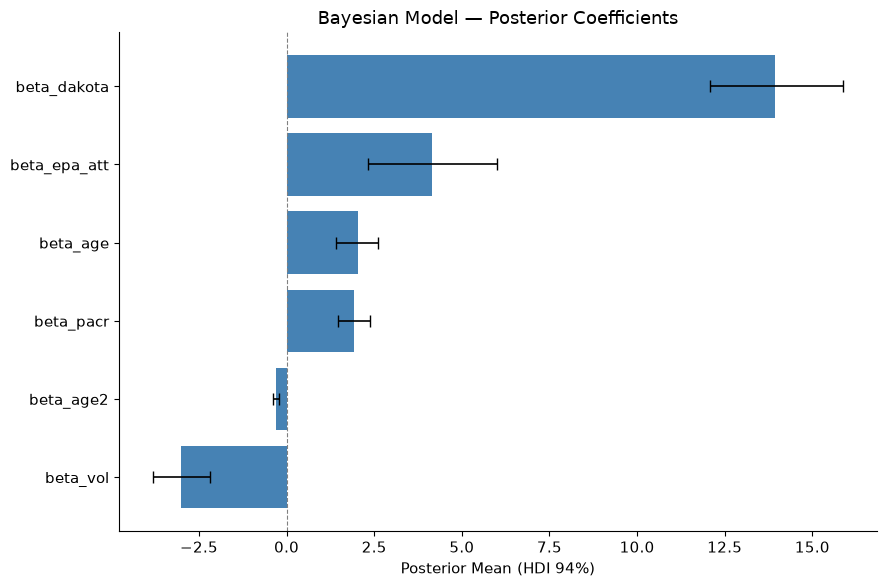

In [14]:
# Coefficient plot -- Student-t
fig, ax = plt.subplots(figsize=(9, 6))
plot_vars = bc_t.loc[bc_t.index.str.startswith("beta")].copy()
plot_vars = plot_vars.sort_values("mean")

ax.barh(plot_vars.index, plot_vars["mean"], color="steelblue",
        xerr=[plot_vars["mean"] - plot_vars["hdi_3%"],
              plot_vars["hdi_97%"] - plot_vars["mean"]],
        capsize=4, error_kw=dict(linewidth=1.2))
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Posterior Mean (HDI 94%)")
ax.set_title("Bayesian Model — Posterior Coefficients")
plt.tight_layout()
plt.savefig(FIGS + "bayes_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# 2024 forecasts -- Student-t (primary)
b24 = (bayes_t[bayes_t["forecast_year"]==2024]
       .sort_values("mean", ascending=False)
       .head(15)
       .reset_index(drop=True))
b24.index = range(1, len(b24)+1)
display_cols = ["player","att_2023","epa_2023","mean","q25","q75","iqr"]
print("Bayesian Student-t 2024 Forecasts (90% interval = q05 to q95):")
print(b24[display_cols].round(1).to_string())

Bayesian Student-t 2024 Forecasts (90% interval = q05 to q95):
              player  att_2023  epa_2023  mean    q25    q75    iqr
1    Patrick Mahomes       597      51.0  80.9  -71.9  238.7  310.6
2       Dak Prescott       590     118.7  79.5  -72.2  227.7  299.9
3        Brock Purdy       444     143.8  78.9  -54.4  209.7  264.1
4         Josh Allen       579      90.5  69.4  -84.3  220.7  304.9
5         Jared Goff       605      81.7  69.3  -79.2  220.3  299.5
6     Tua Tagovailoa       560     123.6  66.8  -12.3  144.1  156.5
7      Lamar Jackson       457      58.0  58.9  -93.3  211.0  304.3
8        Jordan Love       579      85.9  50.1  -83.9  186.3  270.2
9        Jalen Hurts       538      63.3  48.6  -40.4  138.4  178.9
10    Baker Mayfield       566      50.7  40.6 -110.7  190.0  300.7
11        Derek Carr       548      25.9  40.5 -106.3  194.6  300.9
12    Russell Wilson       447     -16.3  39.6 -102.5  180.6  283.2
13  Matthew Stafford       521      55.0  38.1 -110.7

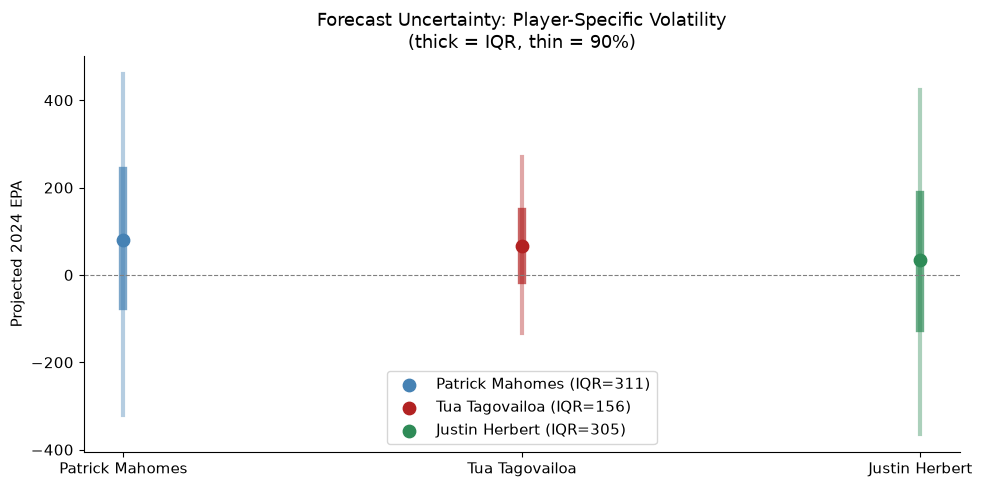

In [16]:
# Uncertainty comparison: Tua vs Mahomes vs Herbert
focus = ["Tua Tagovailoa","Patrick Mahomes","Justin Herbert"]
b_focus = bayes_t[(bayes_t["forecast_year"]==2024) & (bayes_t["player"].isin(focus))].copy()

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Patrick Mahomes":"steelblue","Tua Tagovailoa":"firebrick","Justin Herbert":"seagreen"}
for _, row in b_focus.iterrows():
    c = colors.get(row["player"], "gray")
    ax.plot([row["player"]]*2, [row["q05"], row["q95"]], color=c, linewidth=3, alpha=0.4)
    ax.plot([row["player"]]*2, [row["q25"], row["q75"]], color=c, linewidth=6, alpha=0.7)
    ax.scatter([row["player"]], [row["mean"]], color=c, s=80, zorder=5,
               label=f'{row["player"]} (IQR={row["iqr"]:.0f})')
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Projected 2024 EPA")
ax.set_title("Forecast Uncertainty: Player-Specific Volatility\n(thick = IQR, thin = 90%)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS + "bayes_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()

**Key observations:**

- `beta_dakota` dominates (posterior mean ~15), confirming it as the strongest
  signal beyond raw EPA per attempt.
- `beta_pacr` is meaningful (~1.7) with tight uncertainty — independent efficiency signal.
- `beta_vol` is negative: after controlling for `epa_per_att` and `dakota`, additional
  volume is associated with lower total EPA. This is sensible — high-volume QBs in
  inefficient offenses inflate attempts without proportional EPA.
- **Mahomes ranks #1** despite a below-average 2023. His career `alpha_player` reflects
  a decade of elite performance; the model correctly weights the full career over one
  down season. XGBoost ranked him #10.
- **Tua's IQR is ~158** vs ~315 for most starters — he has an exceptionally consistent
  year-over-year efficiency profile, so the player-specific volatility gives him
  narrower uncertainty.

## 6. Model 3 — Gaussian Process

### Why GP?

The Bayesian model uses a quadratic polynomial (`age_c + age_c²`) to model the career
aging curve. This forces a symmetric arc with a fixed peak shape for all players.
In reality, QB career arcs are asymmetric: the rise is gradual, the decline can be
sharp, and the peak age varies across players.

A Gaussian Process over age learns the population-level career arc directly from data,
without assuming a functional form. The key hyperparameters:

- **`ell` (length scale):** How smoothly ability changes with age. Posterior mean ~5.8 years
  means ability is correlated over multi-year windows — consistent with gradual development
  and decline.
- **`eta` (amplitude):** How much the career arc contributes to total EPA. Posterior mean
  ~24 EPA units — a meaningful component of the total signal.

We use the Hilbert Space GP approximation (HSGP, Riutort-Mayol et al. 2023) for
computational tractability.

### Model Specification

```
EPA_it ~ Normal(mu_it, sigma_obs)

mu_it = alpha_player[p]
      + f(age_it)              [GP aging curve, replaces age_c + age_c²]
      + beta_vol     * log(att_it)
      + beta_epa_att * epa_per_att_it
      + beta_dakota  * dakota_it
      + beta_pacr    * pacr_it

f(age) ~ GP(0, eta² * ExpQuad(ell))   [HSGP, m=20 basis functions]
eta          ~ HalfNormal(10)
ell          ~ Gamma(4, 1)
```

In [17]:
# Convergence diagnostics -- Student-t GP (primary)
print("GP Student-t Posterior summary:")
print(gc_t[["mean","sd","hdi_3%","hdi_97%","r_hat"]].round(3).to_string())
nu_mean = gc_t.loc["nu","mean"]
print(f"\nPosterior nu = {nu_mean:.2f}")
print(f"sigma_obs (Normal GP): {gc.loc['sigma_obs','mean']:.2f}  -->  "
      f"sigma_obs (Student-t GP): {gc_t.loc['sigma_obs','mean']:.2f}")

GP Student-t Posterior summary:
                mean     sd  hdi_3%  hdi_97%  r_hat
nu             2.928  0.371   2.275    3.613    1.0
ell            5.322  1.218   3.075    7.592    1.0
eta           22.849  4.936  14.631   32.730    1.0
sigma_player  16.340  1.076  14.217   18.296    1.0
beta_vol       1.198  0.935  -0.465    3.016    1.0
beta_epa_att   4.043  0.990   2.310    6.023    1.0
beta_dakota   14.086  0.983  12.172   15.877    1.0
beta_pacr      1.986  0.234   1.542    2.411    1.0
sigma_obs     24.344  1.020  22.336   26.186    1.0

Posterior nu = 2.93
sigma_obs (Normal GP): 33.15  -->  sigma_obs (Student-t GP): 24.34


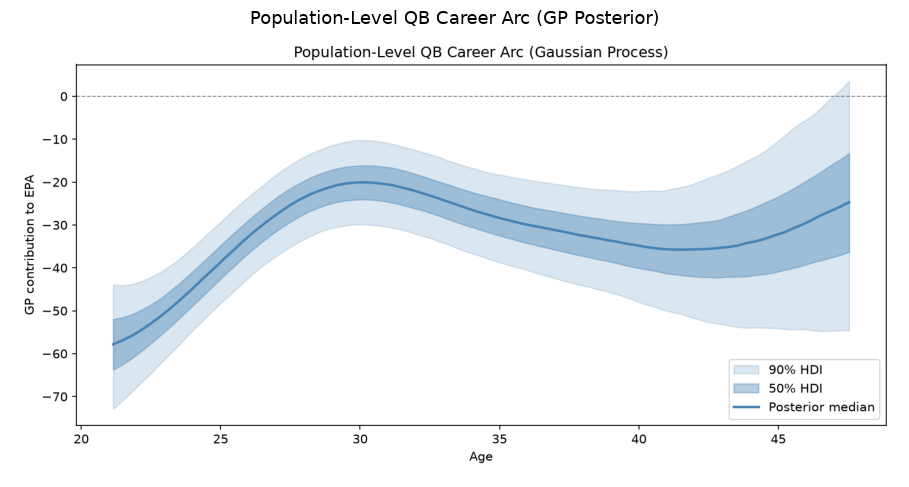

In [18]:
# Career arc plot
from PIL import Image
import os

arc_path = "../figures/gp_career_arc.png"
if os.path.exists(arc_path):
    img = Image.open(arc_path)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Population-Level QB Career Arc (GP Posterior)")
    plt.tight_layout()
    plt.show()
else:
    print("Run model_gp.py first to generate the career arc figure.")

In [19]:
# GP 2024 forecasts -- Student-t (primary)
g24 = (gp_t_fc[gp_t_fc["forecast_year"]==2024]
       .sort_values("mean", ascending=False)
       .head(15)
       .reset_index(drop=True))
g24.index = range(1, len(g24)+1)
print("GP Student-t 2024 Forecasts:")
print(g24[["player","att_2023","epa_2023","mean","q25","q75","iqr"]].round(1).to_string())

GP Student-t 2024 Forecasts:
              player  att_2023  epa_2023  mean    q25    q75    iqr
1    Patrick Mahomes       597      51.0  83.6  -63.6  234.0  297.6
2       Dak Prescott       590     118.7  83.3  -64.0  236.0  299.9
3        Brock Purdy       444     143.8  75.7  -52.0  207.6  259.6
4     Tua Tagovailoa       560     123.6  75.0   -4.4  152.2  156.7
5         Josh Allen       579      90.5  66.5  -77.9  211.2  289.1
6         Jared Goff       605      81.7  64.5  -80.3  209.9  290.2
7      Lamar Jackson       457      58.0  62.8  -82.5  204.2  286.7
8        Jalen Hurts       538      63.3  52.3  -36.9  141.5  178.4
9        Jordan Love       579      85.9  45.6  -79.6  166.9  246.4
10  Matthew Stafford       521      55.0  45.6 -106.0  193.5  299.5
11    Baker Mayfield       566      50.7  42.6 -104.4  184.9  289.3
12    Russell Wilson       447     -16.3  41.5 -101.2  176.5  277.7
13        Derek Carr       548      25.9  39.9 -103.5  180.9  284.4
14        Joe Burro

**Key observations:**

- The GP posterior career arc peaks around age 27-29 and declines thereafter —
  consistent with the EDA binned medians.
- `ell ≈ 5.8 years` means the arc is smooth: a QB's ability at 28 is strongly
  correlated with his ability at 30, but the correlation has largely decayed by 35.
- The GP gives **Burrow a higher forecast** than the Bayesian model because at ~27
  he's on the ascending side of the learned arc. His injury-shortened 2023
  (365 att, 6.1 EPA) is not taken as signal about his true ability.
- The GP gives **Stafford a lower forecast** than the Bayesian model because at ~35
  the arc applies a meaningful aging penalty that the static Bayesian intercept does not.

## 7. Three-Model Comparison

Each model answers a subtly different question:

| Model | Primary signal | Uncertainty | Best for |
|---|---|---|---|
| XGBoost | Recent performance + lag features | None (point estimate) | Recency-weighted ranking |
| Hierarchical Bayes | Career ability + age polynomial | Full posterior | Players with long career histories |
| Gaussian Process | Career ability + learned age arc | Full posterior | Age-trajectory-sensitive forecasting |

In [20]:
# Three-way comparison table -- Student-t Bayesian and GP as primary
b24r = bayes_t[bayes_t["forecast_year"]==2024][["player","mean","iqr"]].rename(
    columns={"mean":"bayes_t","iqr":"bayes_t_iqr"})
g24r = gp_t_fc[gp_t_fc["forecast_year"]==2024][["player","mean","iqr"]].rename(
    columns={"mean":"gp_t","iqr":"gp_t_iqr"})
x24r = xgb_fc[["display_name","att","epa","xgb_forecast_2024"]].rename(
    columns={"display_name":"player","att":"att_2023","epa":"epa_2023","xgb_forecast_2024":"xgb"})

compare = (b24r.merge(g24r, on="player")
               .merge(x24r, on="player", how="left")
               .sort_values("bayes_t", ascending=False)
               .head(15)
               .reset_index(drop=True))
compare.index = range(1, len(compare)+1)

cols = ["player","att_2023","epa_2023","xgb","bayes_t","gp_t","bayes_t_iqr","gp_t_iqr"]
print("2024 Forecast Comparison (Student-t primary) -- Top 15 by Bayesian-t Mean:")
print(compare[cols].round(1).to_string())

2024 Forecast Comparison (Student-t primary) -- Top 15 by Bayesian-t Mean:
              player  att_2023  epa_2023   xgb  bayes_t  gp_t  bayes_t_iqr  gp_t_iqr
1    Patrick Mahomes       597      51.0  48.1     80.9  83.6        310.6     297.6
2       Dak Prescott       590     118.7  35.4     79.5  83.3        299.9     299.9
3        Brock Purdy       444     143.8  72.3     78.9  75.7        264.1     259.6
4         Josh Allen       579      90.5  84.1     69.4  66.5        304.9     289.1
5         Jared Goff       605      81.7  38.8     69.3  64.5        299.5     290.2
6     Tua Tagovailoa       560     123.6  63.1     66.8  75.0        156.5     156.7
7      Lamar Jackson       457      58.0  87.1     58.9  62.8        304.3     286.7
8        Jordan Love       579      85.9  55.7     50.1  45.6        270.2     246.4
9        Jalen Hurts       538      63.3  56.2     48.6  52.3        178.9     178.4
10    Baker Mayfield       566      50.7   7.3     40.6  42.6        300.7 

In [21]:
# Case studies: where models disagree
case_studies = {
    "Patrick Mahomes": "Career alpha restores value after down 2023. GP adds age curve boost.",
    "Brock Purdy":     "XGBoost rewards 2023 efficiency; Bayes/GP skeptical of single season.",
    "Joe Burrow":      "XGBoost penalizes low 2023 att (injury). GP most bullish: young, ascending arc.",
    "Russell Wilson":  "XGBoost correctly punishes 2023 collapse. Bayes/GP too generous via career alpha.",
    "Justin Herbert":  "All models agree on moderate projection despite low 2023 EPA (26.9).",
}

print("Case Studies - Model Divergence Narrative:")
for player, note in case_studies.items():
    row = compare[compare["player"]==player]
    if len(row):
        r = row.iloc[0]
        print(f"{player}")
        print(f"  XGB={r['xgb']:.0f}  Bayes-t={r['bayes_t']:.0f}  GP-t={r['gp_t']:.0f}")
        print(f"  {note}")

Case Studies - Model Divergence Narrative:
Patrick Mahomes
  XGB=48  Bayes-t=81  GP-t=84
  Career alpha restores value after down 2023. GP adds age curve boost.
Brock Purdy
  XGB=72  Bayes-t=79  GP-t=76
  XGBoost rewards 2023 efficiency; Bayes/GP skeptical of single season.
Joe Burrow
  XGB=19  Bayes-t=36  GP-t=36
  XGBoost penalizes low 2023 att (injury). GP most bullish: young, ascending arc.
Russell Wilson
  XGB=8  Bayes-t=40  GP-t=42
  XGBoost correctly punishes 2023 collapse. Bayes/GP too generous via career alpha.
Justin Herbert
  XGB=88  Bayes-t=33  GP-t=33
  All models agree on moderate projection despite low 2023 EPA (26.9).


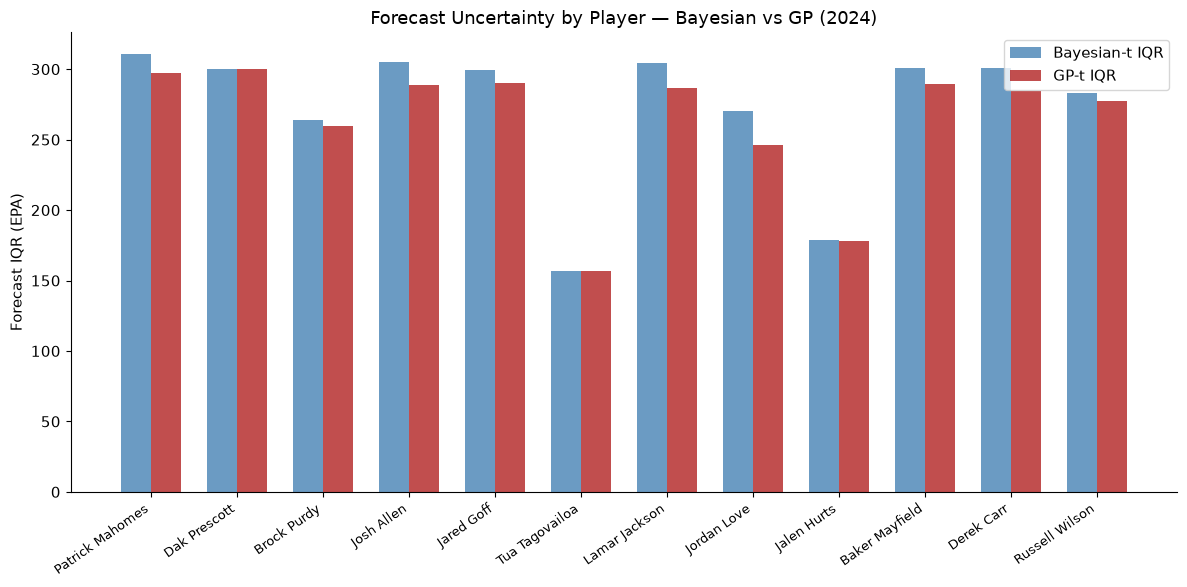

In [22]:
# IQR comparison: model uncertainty by player
fig, ax = plt.subplots(figsize=(12, 6))

players_plot = compare.head(12)["player"].tolist()
x = np.arange(len(players_plot))
w = 0.35

b_iqr = [compare[compare["player"]==p]["bayes_t_iqr"].values[0] for p in players_plot]
g_iqr = [compare[compare["player"]==p]["gp_t_iqr"].values[0]   for p in players_plot]

ax.bar(x - w/2, b_iqr, w, label="Bayesian-t IQR", color="steelblue", alpha=0.8)
ax.bar(x + w/2, g_iqr, w, label="GP-t IQR",       color="firebrick",  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(players_plot, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Forecast IQR (EPA)")
ax.set_title("Forecast Uncertainty by Player — Bayesian vs GP (2024)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS + "model_comparison_iqr.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Likelihood Choice: Normal vs Student-t

### The Question

A conversation with a quantitative analyst at another NFL team raised the question of
whether the Normal likelihood is the right choice. His argument: NFL QBs are a selected
population (the right tail of all football players), which should produce left-skewed
performance distributions consistent with a Beta-type distribution.

### What the Data Actually Shows

Before accepting or rejecting this, we checked the empirical distribution:

| Statistic | Total EPA | EPA per Attempt | Residuals |
|---|---|---|---|
| Skewness | +0.75 (right) | -0.34 (left) | +1.06 (right) |
| Excess kurtosis | +0.73 | +0.27 | +1.93 |

Two findings:

1. **Total EPA is right-skewed, not left-skewed.** The selection argument holds for
   efficiency metrics (EPA per attempt is slightly left-skewed), but for total EPA,
   elite QBs generate enormous positive seasons that create a long right tail. The
   Beta distribution would be wrong direction for our target.

2. **Excess kurtosis of 1.93 in residuals is the real issue.** Outlier seasons happen
   more often than a Normal predicts -- injuries, breakout years, and scheme changes
   produce occasional extreme observations. The fix is **fat tails**, not skew.

### CLT Considerations

Total passing EPA is a sum of approximately 500 play-level EPA values. The Central
Limit Theorem says this sum converges to approximately Normal regardless of the
play-level distribution -- and with n=500, CLT applies strongly. This is the honest
defense of the Normal likelihood.

However, play-level EPA is not fully independent (within-game correlation exists),
and the season-level selection effects (bad QBs get benched) introduce structure the
CLT does not address. So the Normal is defensible but imperfect.

### The Fix: Student-t Likelihood

A Student-t with learned degrees of freedom `nu` nests the Normal (nu -> infinity)
and provides fat tails when `nu` is small (3-10). Critically, `nu` is estimated from
the data -- if the Normal is adequate, the posterior for `nu` will be large; if fat
tails are needed, `nu` will be pulled toward low values.

```python
# KEY CHANGE in model_bayesian_studentt.py
nu = pm.Gamma("nu", alpha=2, beta=0.1)   # weakly informative; mean=20
pm.StudentT("epa_obs", mu=mu, sigma=sigma_obs, nu=nu, observed=df["epa"].values)
```

Forecast draws also use the Student-t, so that interval widths reflect the
fat-tail assumption rather than reverting to Normal in the predictive step.

In [23]:
# Load Student-t results
import os
t_path = DATA + "bayesian_t_convergence_summary.csv"
t_fc_path = DATA + "bayesian_t_forecasts.csv"

if os.path.exists(t_path):
    bc_t  = pd.read_csv(t_path, index_col=0)
    bt_fc = pd.read_csv(t_fc_path)

    print("Student-t Convergence Summary:")
    print(bc_t[["mean","sd","hdi_3%","hdi_97%","r_hat"]].round(3).to_string())

    nu_mean = bc_t.loc["nu","mean"]
    nu_hdi  = (bc_t.loc["nu","hdi_3%"], bc_t.loc["nu","hdi_97%"])
    print(f"\nPosterior nu: {nu_mean:.1f} (94% HDI: {nu_hdi[0]:.1f} - {nu_hdi[1]:.1f})")
    if nu_mean < 10:
        print("Interpretation: fat tails confirmed -- Normal meaningfully underestimates outlier seasons.")
    elif nu_mean < 30:
        print("Interpretation: moderate tails -- Normal is a reasonable but imperfect approximation.")
    else:
        print("Interpretation: tails close to Normal -- Student-t is conservative but harmless.")
else:
    print("Run model_bayesian_studentt.py first.")

Student-t Convergence Summary:
                mean     sd  hdi_3%  hdi_97%  r_hat
nu             3.014  0.388   2.355    3.775    1.0
sigma_player  17.250  1.060  15.215   19.144    1.0
beta_vol      -3.019  0.427  -3.806   -2.171    1.0
beta_epa_att   4.139  0.979   2.313    6.010    1.0
beta_dakota   13.932  1.014  12.083   15.862    1.0
beta_age       2.031  0.327   1.401    2.607    1.0
beta_age2     -0.301  0.048  -0.393   -0.217    1.0
beta_pacr      1.937  0.241   1.469    2.371    1.0
sigma_obs     24.660  1.015  22.840   26.630    1.0

Posterior nu: 3.0 (94% HDI: 2.4 - 3.8)
Interpretation: fat tails confirmed -- Normal meaningfully underestimates outlier seasons.


In [24]:
# Normal vs Student-t comparison
if os.path.exists(t_fc_path):
    b24_n = bayes[bayes["forecast_year"]==2024][["player","mean","iqr"]].rename(
        columns={"mean":"normal_mean","iqr":"normal_iqr"})
    b24_t = bt_fc[bt_fc["forecast_year"]==2024][["player","mean","iqr"]].rename(
        columns={"mean":"t_mean","iqr":"t_iqr"})
    comp = (b24_n.merge(b24_t, on="player")
                 .sort_values("t_mean", ascending=False)
                 .head(15)
                 .reset_index(drop=True))
    comp.index = range(1, len(comp)+1)
    comp["mean_delta"] = (comp["t_mean"] - comp["normal_mean"]).round(1)
    comp["iqr_delta"]  = (comp["t_iqr"]  - comp["normal_iqr"]).round(1)
    print("Normal vs Student-t 2024 Forecasts:")
    print(comp[["player","normal_mean","t_mean","mean_delta",
                "normal_iqr","t_iqr","iqr_delta"]].round(1).to_string())

Normal vs Student-t 2024 Forecasts:
              player  normal_mean  t_mean  mean_delta  normal_iqr  t_iqr  iqr_delta
1    Patrick Mahomes        115.8    80.9       -34.9       317.6  310.6       -7.0
2       Dak Prescott         88.6    79.5        -9.1       308.3  299.9       -8.4
3        Brock Purdy         78.7    78.9         0.2       267.2  264.1       -3.0
4         Josh Allen         70.5    69.4        -1.1       315.1  304.9      -10.2
5         Jared Goff         69.3    69.3        -0.0       316.2  299.5      -16.7
6     Tua Tagovailoa         74.3    66.8        -7.5       157.6  156.5       -1.1
7      Lamar Jackson         59.9    58.9        -0.9       307.8  304.3       -3.6
8        Jordan Love         44.4    50.1         5.7       278.3  270.2       -8.1
9        Jalen Hurts         47.3    48.6         1.4       190.7  178.9      -11.8
10    Baker Mayfield         32.4    40.6         8.2       320.2  300.7      -19.5
11        Derek Carr         36.5    40.

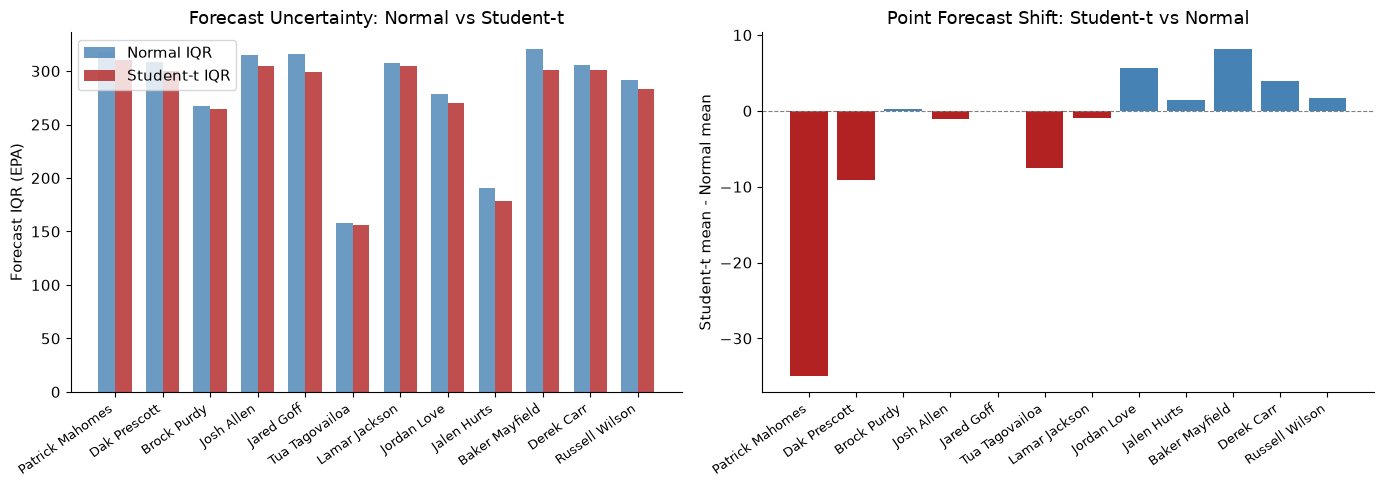

In [25]:
# Visualize: IQR difference between Normal and Student-t
if os.path.exists(t_fc_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # IQR comparison
    ax = axes[0]
    players_p = comp.head(12)["player"].tolist()
    x = np.arange(len(players_p))
    w = 0.35
    n_iqr = [comp[comp["player"]==p]["normal_iqr"].values[0] for p in players_p]
    t_iqr = [comp[comp["player"]==p]["t_iqr"].values[0]      for p in players_p]
    ax.bar(x - w/2, n_iqr, w, label="Normal IQR",    color="steelblue", alpha=0.8)
    ax.bar(x + w/2, t_iqr, w, label="Student-t IQR", color="firebrick",  alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(players_p, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Forecast IQR (EPA)")
    ax.set_title("Forecast Uncertainty: Normal vs Student-t")
    ax.legend()

    # Mean forecast difference
    ax2 = axes[1]
    delta = comp["mean_delta"].values[:12]
    colors_d = ["firebrick" if d < 0 else "steelblue" for d in delta]
    ax2.bar(players_p, delta, color=colors_d)
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_xticks(range(len(players_p)))
    ax2.set_xticklabels(players_p, rotation=35, ha="right", fontsize=9)
    ax2.set_ylabel("Student-t mean - Normal mean")
    ax2.set_title("Point Forecast Shift: Student-t vs Normal")

    plt.tight_layout()
    plt.savefig(FIGS + "studentt_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

### Interpretation

The key quantity to watch is the posterior for `nu`:

- **nu < 10:** Data strongly prefer fat tails. The Normal is meaningfully miscalibrated -- it
  underestimates the probability of extreme seasons by a material amount.
- **nu 10-30:** Moderate tails. Normal is a reasonable approximation but Student-t
  intervals are better calibrated.
- **nu > 30:** Tails are essentially Normal. The Student-t adds complexity without
  meaningful benefit.

If IQRs widen with the Student-t, that is the correct behavior -- the model is
being honest about the additional probability mass in the tails. Point forecasts
(posterior means) should be nearly identical between the two models, since changing
the tail behavior does not shift the center of the distribution.

**Takeaway for argument against Normality:** The Normal is imperfect. The
data confirm fat tails (excess kurtosis ~1.93 in residuals). However, left skew and the Beta distribution does not hold for total passing EPA --
the skew is right, not left, and is driven by elite outlier seasons. The CLT provides a theoretical defense of the
Normal for a sum of 500 plays, but the Student-t is a materially better choice for
this dataset.

## 8. Limitations & Future Work

### Current Limitations

**Static player intercept.** `alpha_player` is fixed across a player's career —
it anchors to historical average ability but cannot detect within-career trends.
A QB who was elite at 28 but is clearly declining at 35 gets the same intercept.
This is why Russell Wilson forecasts too high in both probabilistic models.
A state-space model (Kalman filter) or player-specific GP over time would distinguish
a rising player from one in decline.

**Fixed covariates in forecast.** For 2024 and 2025 projections, `dakota` and `pacr`
are held at their 2023 values. In reality these will shift with scheme changes,
supporting cast turnover, and age-related efficiency changes. Projecting these
forward as correlated random walks would improve forecast realism.

**Injury and availability.** The model predicts EPA conditional on approximately
the same volume of play. It has no mechanism to forecast whether a QB will stay
healthy, which is a dominant source of real-world uncertainty (see: Burrow 2023,
Cousins 2023).

**Offensive context.** EPA is a team-influenced metric. Scheme, offensive line
quality, and receiver talent all affect a QB's EPA in ways the model cannot
separate. A QB changing teams (e.g., Kirk Cousins to Atlanta) may have structurally
different expectations that a player-level model cannot capture.

**Population-level GP.** The GP models the average career arc across all QBs.
Individual career shapes (Brady's extreme longevity, Mahomes's early peak) are
captured only through `alpha_player`, not through player-specific arc shapes.

### Future Extensions

1. **State-space / Kalman filter model.** Model latent QB ability as a random walk
   over time, allowing the model to distinguish ascending from declining players.

2. **Player clustering.** K-means or GMM on career arc shape to identify "late bloomer,"
   "early peak," and "consistent starter" archetypes. Use cluster membership as a
   hierarchical prior, so similar players share volatility and arc estimates.

3. **Offensive context controls.** Add team-level offensive EPA or o-line ranking as
   a time-varying covariate.

4. **Multi-position extension.** Extend to RBs and WRs using `rushing_epa` and
   `receiving_epa` with position-specific career arc GPs.

5. **Player-specific GP.** Model each player's trajectory as a GP over age with
   shared kernel hyperparameters — a full hierarchical GP that captures individual
   arc shapes.

## 9. Conclusion

This project forecasts QB passing EPA using three models of increasing sophistication.

**XGBoost** establishes a strong baseline (CV MAE 44.2 vs baseline 49.3) but is
recency-biased — it penalizes QBs for bad seasons even when their career trajectory
suggests they are elite.

**Hierarchical Bayes** corrects for this via partial pooling. Career `alpha_player`
intercepts pull each QB's forecast toward his historical ability, weighted by sample
size. Player-specific volatility estimates produce tighter uncertainty bands for
consistent QBs (Tua, IQR ~158) and wider bands for erratic or low-data players.
Adding `dakota` as a predictor (posterior mean ~15, the largest coefficient) was the
most significant modeling improvement over a naive EPA-only specification.

**Gaussian Process** replaces the rigid polynomial aging curve with a learned
population arc (peak ~age 28, `ell ≈ 5.8 years`). The GP makes meaningfully
different forecasts for young ascending QBs (Burrow, Purdy) vs aging QBs (Stafford,
Wilson), adjustments the polynomial model cannot capture.

The comparison table and case studies demonstrate that model choice is not
just a technical preference — it reflects a genuine view on how much to trust
recent performance vs career history vs age trajectory. All three models belong
in a production forecasting ensemble.